In [11]:
import pandas as pd

X_train = pd.read_csv("X_train.csv") 
X_val   = pd.read_csv("X_val.csv")

y_train = pd.read_csv("y_train.csv").iloc[:, 0]
y_val   = pd.read_csv("y_val.csv").iloc[:, 0]


print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)
print(y_train.value_counts())


(73271, 44) (18318, 44) (73271,) (18318,)
readmitted
0    39484
1    25591
2     8196
Name: count, dtype: int64


In [12]:
# K-Nearest Neighbours (KNN) is a distance-based, instance-based learning algorithm
# The baseline model uses K=5 neighbours with uniform weighting
# Feature scaling is essential for KNN as distance calculations are scale-sensitive
# StandardScaler is required for KNN to prevent features with larger ranges
# from dominating distance calculations

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

cat_cols = X_train.select_dtypes(include="object").columns
num_cols = X_train.select_dtypes(exclude="object").columns

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

knn = Pipeline([
    ("preprocess", preprocess),
    ("clf", KNeighborsClassifier(n_neighbors=5))
])

knn.fit(X_train, y_train)
pred = knn.predict(X_val)

print(classification_report(y_val, pred, digits=3))
print(confusion_matrix(y_val, pred))


              precision    recall  f1-score   support

           0      0.583     0.756     0.659      9871
           1      0.423     0.339     0.376      6398
           2      0.259     0.051     0.086      2049

    accuracy                          0.531     18318
   macro avg      0.422     0.382     0.373     18318
weighted avg      0.491     0.531     0.496     18318

[[7461 2280  130]
 [4061 2167  170]
 [1265  679  105]]


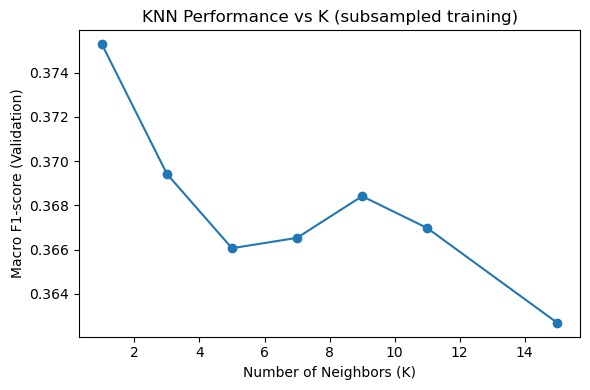

Best K = 1 Best Macro F1 = 0.3752766606181992


In [13]:
# Different values of K are evaluated to study their impact on model performance
# Macro-averaged F1-score is used to prioritise balanced performance
# across all readmission classes

from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

X_sub, _, y_sub, _ = train_test_split(
    X_train, y_train,
    train_size=12000,
    random_state=42,
    stratify=y_train
)

K_list = [1, 3, 5, 7, 9, 11, 15]
macro_f1 = []

for k in K_list:
    model = Pipeline([
        ("preprocess", preprocess),
        ("clf", KNeighborsClassifier(n_neighbors=k))
    ])
    model.fit(X_sub, y_sub)
    pred_k = model.predict(X_val)
    macro_f1.append(f1_score(y_val, pred_k, average="macro"))

plt.figure(figsize=(6,4))
plt.plot(K_list, macro_f1, marker="o")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Macro F1-score (Validation)")
plt.title("KNN Performance vs K (subsampled training)")
plt.tight_layout()
plt.show()

best_k = K_list[int(np.argmax(macro_f1))]
print("Best K =", best_k, "Best Macro F1 =", max(macro_f1))



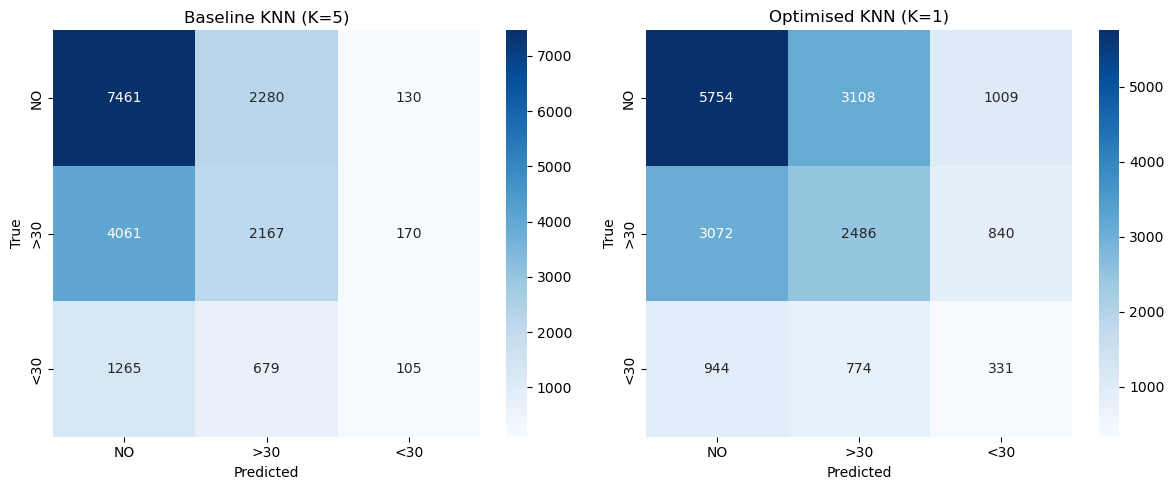

In [14]:
knn_base = Pipeline([
    ("preprocess", preprocess),
    ("clf", KNeighborsClassifier(n_neighbors=5))
])
knn_opt = Pipeline([
    ("preprocess", preprocess),
    ("clf", KNeighborsClassifier(n_neighbors=1))
])

knn_opt.fit(X_train, y_train)
pred_opt = knn_opt.predict(X_val)

knn_base.fit(X_train, y_train)
pred_base = knn_base.predict(X_val)

# Confusion matrices are used to compare baseline and optimised KNN models
# The optimised model shows improved detection of minority classes
# at the cost of reduced performance on the majority class

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_base = confusion_matrix(y_val, pred_base)
cm_opt  = confusion_matrix(y_val, pred_opt)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(cm_base, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NO", ">30", "<30"],
            yticklabels=["NO", ">30", "<30"],
            ax=axes[0])
axes[0].set_title("Baseline KNN (K=5)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_opt, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NO", ">30", "<30"],
            yticklabels=["NO", ">30", "<30"],
            ax=axes[1])
axes[1].set_title("Optimised KNN (K=1)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()


In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

# Optimised KNN (K=1)
knn_opt = Pipeline([
    ("preprocess", preprocess),
    ("clf", KNeighborsClassifier(n_neighbors=1))
])

knn_opt.fit(X_train, y_train)

pred_opt = knn_opt.predict(X_val)

print(classification_report(y_val, pred_opt, digits=3))


              precision    recall  f1-score   support

           0      0.589     0.583     0.586      9871
           1      0.390     0.389     0.389      6398
           2      0.152     0.162     0.157      2049

    accuracy                          0.468     18318
   macro avg      0.377     0.378     0.377     18318
weighted avg      0.471     0.468     0.469     18318

